# Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from skmultilearn.model_selection import IterativeStratification
from tensorflow.keras import layers, models
from collections import Counter
import numpy as np
import PIL
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import MultiLabelBinarizer
import os
import re, string
import pathlib  # 객체지향 방식으로 파일 경로를 다룸
import urllib.request # url을 통해 파일 다운로드 기능 제공
import tarfile
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\human-23\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Data

## Import Data

In [2]:
df = pd.read_csv('./dataset/PubMed.csv').copy()

## Clean Data

### Necessary Content

In [3]:
# 학습에 사용될 자료
df['Content'] = df['Title'].fillna('') + ": " + df['abstractText'].fillna('')
df['Content'].head()


0    Expression of p53 and coexistence of HPV in pr...
1    Vitamin D status in pregnant Indian women acro...
2    [Identification of a functionally important di...
3    Multilayer capsules: a promising microencapsul...
4    Nanohydrogel with N,N'-bis(acryloyl)cystine cr...
Name: Content, dtype: object

### Stopping Word 제거

In [4]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    if pd.isna(text): return ""
    words = text.split()
    filtered_words = [w for w in words if w.lower() not in stop_words]
    return " ".join(filtered_words)

df['Content'] = df['Content'].apply(remove_stopwords)
df['Content'].head()

0    Expression p53 coexistence HPV premalignant le...
1    Vitamin status pregnant Indian women across tr...
2    [Identification functionally important dipepti...
3    Multilayer capsules: promising microencapsulat...
4    Nanohydrogel N,N'-bis(acryloyl)cystine crossli...
Name: Content, dtype: object

---
### **MeSH 데이터 분류 체계 요약 (MeSH Data Classification Table)**

| 항목 (Term) | 한국어 명칭 (Korean) | 의미 (What: Semantic Domain) | 데이터 깊이 (Depth: Granularity) |
| :--- | :--- | :--- | :--- |
| **MeSH Root** (A-Z) | **MeSH 대분류** | 데이터가 속한 **가장 넓은 범위의 카테고리** (예: 질병, 화합물) | **Low (Level 1)**: 너무 포괄적이라 필터링 효율이 낮음 |
| **MeSH 3-Digit** (C08, C14 등) | **MeSH 중분류** (추출 타겟) | **특정 의학 전문 분야 (Domain)** 정의 (예: 호흡기계, 심혈관계) | **Medium (Level 2)**: 학습에 가장 적합한 **최적의 해상도** (Goldilocks Zone) |
| **MeSH Major** | **주요 주제어** | 논문에서 다루는 **핵심 키워드**들의 리스트 (인간이 읽기 좋은 텍스트) | **High (Specific)**: 매우 구체적이지만 데이터 희소성(Sparsity) 문제가 발생할 수 있음 |

---

In [5]:
# Mesh Subtitle 추출
# Mesh Subtitle = 논문 중분류 ()
def extract_3_digit_levels(mesh_data):
    # Alphabet + Letter + Letter 찾음
    codes = re.findall(r'[A-Z][0-9]{2}', str(mesh_data))
    # Return as a unique list to avoid duplicates for the same paper
    return list(set(codes))

# Apply the function to create a new organized column
df['mesh_sub_branches'] = df['meshid'].apply(extract_3_digit_levels)
df['mesh_sub_branches'].head()

0    [E01, D13, D27, B04, C04, B01, D12, E05, C13, ...
1    [G08, D08, D27, G16, N06, C18, Z01, D04, F01, ...
2    [E01, A02, G11, D27, A10, L01, B01, D12, G02, ...
3    [D02, D09, A11, D27, G02, E02, D25, D01, A10, ...
4    [D02, E02, D09, G03, D01, A11, D04, D27, D26, ...
Name: mesh_sub_branches, dtype: object

### Drop Other columns

In [6]:
cols_to_drop = ['pmid', 'meshMajor', 'meshroot', 'Title', 'abstractText', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'L', 'M', 'N', 'Z']
df.drop(columns=cols_to_drop, axis=1, inplace=True, errors='ignore')
print(f"남은 컬럼: {df.columns.tolist()}")

남은 컬럼: ['meshid', 'Content', 'mesh_sub_branches']


## Multi Hot Encoding

In [7]:
# 1. 모든 행의 리스트를 평탄화(flatten)하여 빈도수 계산
all_codes = [code for sublist in df['mesh_sub_branches'] for code in sublist]
code_counts = Counter(all_codes)

# 2. 가장 많이 등장하는 상위 50개 코드 추출
# most_common(50)은 (코드, 빈도수) 튜플 리스트를 반환하므로 코드만 뽑아냅니다.
top_50_codes = [code for code, count in code_counts.most_common(50)]

# 3. 각 행의 리스트에서 상위 50개에 포함되지 않는 코드는 제거 (필터링)
def filter_top_50(code_list):
    return [code for code in code_list if code in top_50_codes]

df['mesh_sub_branches_top50'] = df['mesh_sub_branches'].apply(filter_top_50)

# 4. 필터링된 데이터를 바탕으로 Multi-hot Encoding 진행
# classes 인자를 사용하여 컬럼 순서를 고정할 수 있습니다.
mlb = MultiLabelBinarizer(classes=top_50_codes)
mhe_data = mlb.fit_transform(df['mesh_sub_branches_top50'])

# 5. 결과 데이터프레임 생성 및 병합
mhe_df = pd.DataFrame(mhe_data, columns=mlb.classes_)
df = pd.concat([df[['Content']], mhe_df], axis=1)

print(f"필터링 전 총 코드 수: {len(code_counts)}")
print(f"최종 선택된 레이블 수: {len(mlb.classes_)}")
print(f"최종 데이터프레임 컬럼: {df.columns.tolist()}")

필터링 전 총 코드 수: 112
최종 선택된 레이블 수: 50
최종 데이터프레임 컬럼: ['Content', 'B01', 'E05', 'M01', 'N06', 'E01', 'N05', 'D12', 'G02', 'G07', 'C23', 'A11', 'D27', 'D02', 'G05', 'E02', 'G01', 'Z01', 'D23', 'D08', 'L01', 'D03', 'C04', 'D01', 'N04', 'E04', 'F01', 'G03', 'G04', 'D13', 'H01', 'N02', 'G16', 'C10', 'C01', 'N01', 'G11', 'J01', 'C14', 'A08', 'A10', 'F02', 'I01', 'D09', 'D04', 'A15', 'B03', 'G09', 'E07', 'C06', 'A02']


### DF 확인

In [8]:
df.head()

,Content,B01,E05,M01,N06,E01,N05,D12,G02,G07,...,F02,I01,D09,D04,A15,B03,G09,E07,C06,A02
0,Expression p53 coexistence HPV premalignant le...,1,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Vitamin status pregnant Indian women across tr...,1,1,1,1,0,1,1,0,1,...,0,1,0,1,0,0,0,0,0,0
2,[Identification functionally important dipepti...,1,1,0,0,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,1
3,Multilayer capsules: promising microencapsulat...,1,1,0,0,0,0,1,1,0,...,0,0,1,0,0,0,0,1,0,1
4,"Nanohydrogel N,N'-bis(acryloyl)cystine crossli...",1,0,0,0,0,0,1,1,1,...,0,0,1,1,0,0,0,0,0,0


# Explatory Data Analysis

## 불균형 Data 확인

C:\Users\human-23\AppData\Local\Temp\ipykernel_1972\3226276095.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


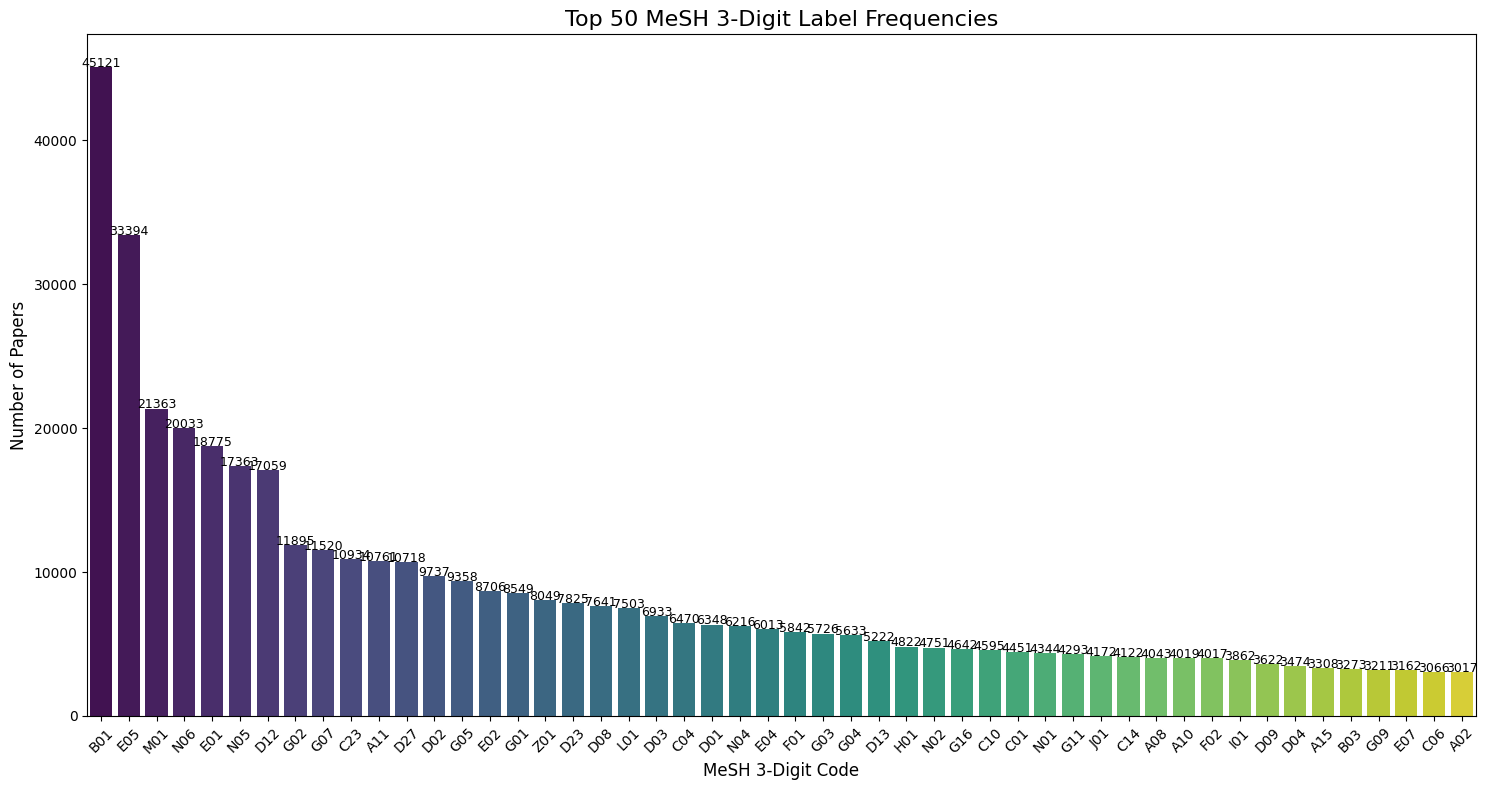

In [9]:
# 1. 'Content' 컬럼을 제외한 모든 레이블 컬럼 선택 (상위 50개)
target_cols = [col for col in df.columns if col != 'Content']

# 2. 각 레이블(컬럼)별 1의 개수 합산 및 정렬
label_counts = df[target_cols].sum().sort_values(ascending=False)

# 3. 막대 그래프(Bar Chart) 시각화
plt.figure(figsize=(15, 8))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')

plt.title('Top 50 MeSH 3-Digit Label Frequencies', fontsize=16)
plt.xlabel('MeSH 3-Digit Code', fontsize=12)
plt.ylabel('Number of Papers', fontsize=12)
plt.xticks(rotation=45) # 라벨이 겹치지 않도록 회전

# 그래프 위에 수치 표시
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 5, str(int(v)), color='black', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 

## Content 길이 확인

count    50000.000000
mean       134.321220
std         53.491773
min         10.000000
25%         97.000000
50%        134.000000
75%        170.000000
90%        199.000000
95%        219.000000
max        705.000000
Name: word_count, dtype: float64


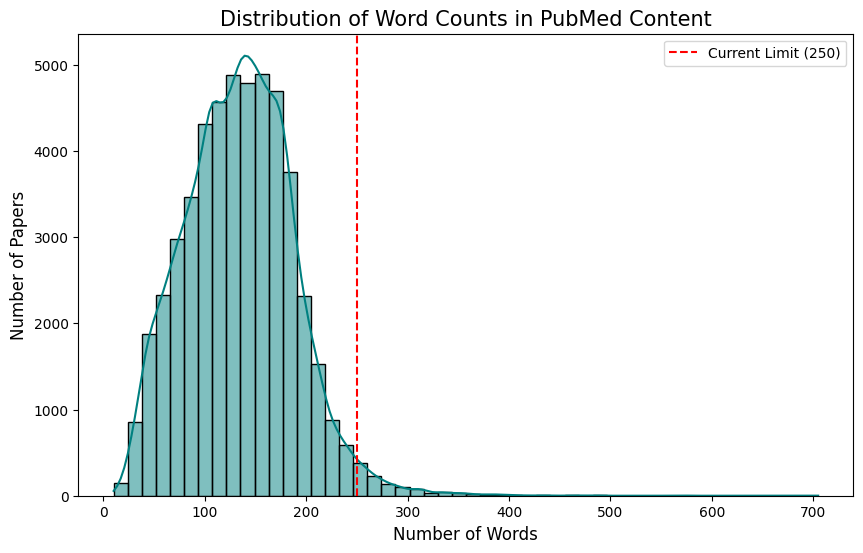

In [10]:
# 1. 각 논문(Content)의 단어 수 계산
df['word_count'] = df['Content'].apply(lambda x: len(str(x).split()))

# 2. 통계치 확인 (평균, 최대, 최소, 백분위수)
print(df['word_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))

# 3. 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True, color='teal')

# 이전 모델로 설정된 250단어 지점에 빨간 세로선 표시
plt.axvline(x=250, color='red', linestyle='--', label='Current Limit (250)')

plt.title('Distribution of Word Counts in PubMed Content', fontsize=15)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Number of Papers', fontsize=12)
plt.legend()
plt.show()

# 200 단어로 시작할 예정임

## 희소성 확인

In [11]:
# 1. 각 행(논문)별로 할당된 레이블의 총합 계산
# target_cols는 앞서 만든 상위 50개 컬럼 리스트임.
df['label_sum'] = df[target_cols].sum(axis=1)

# 2. 레이블이 0개인(어떤 카테고리에도 속하지 않는) 논문 수 계산
zero_label_papers = df[df['label_sum'] == 0]
num_zero_labels = len(zero_label_papers)
total_papers = len(df)

# 3. 희소성 비율(Sparsity Ratio) 계산
sparsity_ratio = (num_zero_labels / total_papers) * 100

print(f"전체 논문 수: {total_papers}")
print(f"레이블이 하나도 없는 논문 수: {num_zero_labels}")
print(f"데이터 손실률(희소성): {sparsity_ratio:.2f}%")

# 4. 논문당 평균 레이블 수 확인
avg_labels = df['label_sum'].mean()
print(f"논문당 평균 레이블 수: {avg_labels:.2f}")

전체 논문 수: 50000
레이블이 하나도 없는 논문 수: 362
데이터 손실률(희소성): 0.72%
논문당 평균 레이블 수: 8.66


## EDA column drop

In [12]:
# EDA용으로 만들었던 컬럼들 삭제
df.drop(columns=['word_count', 'label_sum'], inplace=True)

# Train Test Split

## X,y

In [13]:
# Feature
X = df['Content'].values

# Labels
y = df.drop(columns=['Content']).values.astype('float32')

## Method

In [14]:
# 1. 반복적 층화 추출기 설정
# 8:2 비율로 나누기 위해 n_splits=5 (1/5 = 20%) 설정
stratifier = IterativeStratification(n_splits=5, order=1)

# 2. 인덱스 추출 (첫 번째 폴드만 사용하여 train/test 분리)
train_indexes, test_indexes = next(stratifier.split(X.reshape(-1, 1), y))

X_train, y_train = X[train_indexes], y[train_indexes]
X_test, y_test = X[test_indexes], y[test_indexes]

print(f"Train set labels mean: {y_train.mean():.4f}")
print(f"Test set labels mean: {y_test.mean():.4f}")

Train set labels mean: 0.1732
Test set labels mean: 0.1733


## Text Vectorization

In [15]:
# 1. 레이어 정의
max_tokens = 10000  # 가장 빈번하게 등장하는 단어 10,000개만 사용
output_sequence_length = 200  # EDA 결과에 따라 200으로 설정

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',  # 각 단어를 정수로 변환
    output_sequence_length=output_sequence_length  # 200단어로 길이를 맞춤 (패딩/절단)
)

# 2. 어휘 사전(Vocabulary) 구축
# 학습 데이터(X_train)만 사용하여 어떤 단어가 있는지 학습함
vectorize_layer.adapt(X_train)

# 3. 샘플 확인
sample_text = [X_train[0]]
vectorized_sample = vectorize_layer(sample_text)
print(f"원본 텍스트 일부: {sample_text[0][:50]}...")
print(f"벡터화 결과: {vectorized_sample.numpy()}")

원본 텍스트 일부: Expression p53 coexistence HPV premalignant lesion...
벡터화 결과: [[  12 1344 9538 2133    1  343  972   36    1    1 4837  114 1741    2
  3989  556   49  972   36 1078   49 1219 2133  195  113   11  925 9430
     6 1280    1 3345 1263   95  590 3791    1  966  223  138  275 1793
    72    6    1    1 5427 1509    1   84  122  358  416  394 1078  113
  1344   12 3399 1954   72 2133  141  552   26 3989  972   36  972   36
   910 2133  416  394   37 6308  103   31 1344   62 2712 4775 5364  308
    52  115 1344    1   95    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0  

# Model

## Model 비교 및 Compile 관련 Variables

In [17]:
label_counts = df.drop(columns=['Content']).sum().values
total_samples = len(df)
num_classes = 50

# 가중치 계산 공식: total / (n_classes * class_count)
weights = total_samples / (num_classes * label_counts)
class_weight_dict = {i: weight for i, weight in enumerate(weights)}

## Model 비교

In [19]:
# 1. 다양한 모델을 생성하는 함수 정의
def build_model(model_type, num_classes=50):
    model = models.Sequential([
        vectorize_layer,
        layers.Embedding(input_dim=10000, output_dim=128, mask_zero=(model_type != 'cnn')),
    ])
    
    if model_type == 'bilstm': # 기존 모델
        model.add(layers.Bidirectional(layers.LSTM(64)))
    elif model_type == 'gru':
        model.add(layers.Bidirectional(layers.GRU(64)))
    elif model_type == 'cnn':
        model.add(layers.Conv1D(128, 5, activation='relu'))
        model.add(layers.GlobalMaxPooling1D())
        
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', 
                  metrics=['binary_accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])
    return model

# 2. 루프를 통한 모델별 학습 및 결과 수집
model_names = ['bilstm', 'gru', 'cnn']
results = []

for name in model_names:
    print(f"--- Training Model: {name} ---")
    current_model = build_model(name)
    history = current_model.fit(
        X_train, y_train,
        epochs=10, # 비교를 위해 에폭 통일
        batch_size=64,
        validation_data=(X_test, y_test),
        class_weight=class_weight_dict,
        verbose=1
    )
    
    # 마지막 에폭의 검증 메트릭 저장
    val_metrics = {
        'model': name,
        'accuracy': history.history['val_binary_accuracy'][-1],
        'precision': history.history['val_precision'][-1],
        'recall': history.history['val_recall'][-1]
    }
    results.append(val_metrics)

# 3. 결과 비교 데이터프레임 생성
comparison_df = pd.DataFrame(results)
print(comparison_df)

--- Training Model: bilstm ---
Epoch 1/10
474/625 ━━━━━━━━━━━━━━━━━━━━ 25s 166ms/step - binary_accuracy: 0.8035 - loss: 0.0113 - precision: 0.4523 - recall: 0.2556

KeyboardInterrupt: 

## Model Constructor

In [ ]:
model = models.Sequential([
    # 1. 텍스트 벡터화 레이어 (앞에서 만든 것)
    vectorize_layer,
    
    # 2. 임베딩 레이어 (10,000단어 -> 128차원 압축)
    layers.Embedding(input_dim=10000, output_dim=128, mask_zero=True),
    
    # 3. 양방향 LSTM (각 방향 64유닛, 합쳐서 128차원 출력)
    # dropout은 일반 뉴런, recurrent_dropout은 순환 연결에 대한 규제야.
    layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    
    # 4. 출력층 (51개 레이블을 각각 0~1 사이 확률로 예측)
    layers.Dense(50, activation='sigmoid')
])

## Model Compile

In [ ]:


# 멀티-라벨 분류이므로 binary_crossentropy를 사용합니다.
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Training

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict  # 불균형 해소 적용
)